In [1]:
import ast
import sys
import os
from itertools import product

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
import pandas as pd
import plotly.express as px
import torch.nn.functional as F
from torch import nn
from scipy.io import loadmat
from torch.utils.data import DataLoader
from tqdm import tqdm
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import balanced_accuracy_score

sys.path.insert(1, "/".join(os.path.abspath("").split("/")[0:-1]))
import models

from importlib import reload

reload(models)

<module 'models' from '/coc/flash12/cli726/_PoissonGradEstim/main/negative_binomial/models.py'>

In [2]:
method_list = ["score", "GS", "GS2", "exp-sigmoid", "exp-cubic"]
tau_list = [0.02, 0.05, 0.1, 0.2, 0.5]
seed_list = np.arange(0, 5)

In [3]:
# tag = "baseline"
tag = "linear"

df_result = []
idx = 0
for (
    method,
    tau,
    seed,
) in product(
    method_list,
    tau_list,
    seed_list,
):
    results_folder = f"results_{tag}/{method}_{tau}_{seed}"
    try:
        df_temp = pd.read_csv(f"{results_folder}/metrics_last.csv")
        df_temp["method"] = method
        df_temp["tau"] = tau
        df_temp["seed"] = seed
        df_result.append(df_temp)
    except:
        print(
            idx,
            f"{results_folder} not found",
        )
    idx += 1

df_result = pd.concat(df_result, ignore_index=True)

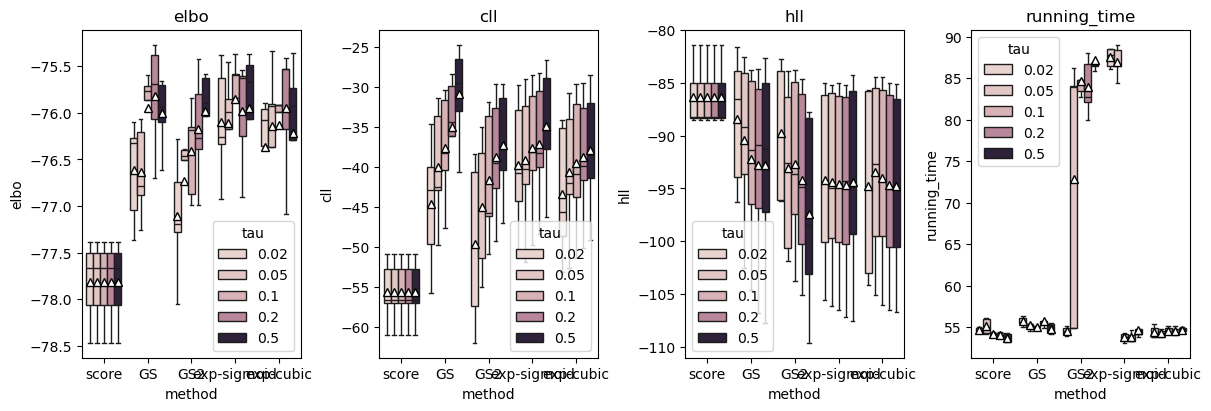

In [4]:
fig, axs = plt.subplots(1, 4, figsize=(12, 4), layout="constrained")

for ax, metric in zip(
    axs.flat,
    ["elbo", "cll", "hll", "running_time"],
):
    sns.boxplot(
        # data=df_result[(df_result["temp"] == 0.1) & (df_result["n_monte_carlo"] == 10)],
        data=df_result,
        x="method",
        hue="tau",
        y=metric,
        ax=ax,
        showfliers=False,
        showmeans=True,
        meanprops={
            "markerfacecolor": "white",
            "markeredgecolor": "black",
        },
    )
    ax.set_title(metric)